# Telco Customer Churn Prediction (Improved Pipeline)

### Key Improvements Over Baseline (`chrunPipe.ipynb`):
1. **Zero Data Leakage:** In the baseline, decision thresholds were tuned directly by evaluating on `y_test`. Here, we use **5-fold Out-Of-Fold (OOF) cross-validation on `X_train`** to find the optimal decision threshold, keeping `X_test` strictly as an unseen holdout set.
2. **Clean Dummy Encoding (Eliminated Redundancies):** In the baseline, categories like `No internet service` produced 6 duplicate, collinear one-hot columns. Here, sub-services are normalized to `'No'` prior to encoding, producing a clean, non-collinear feature space.
3. **Domain Feature Engineering:** Added behavioral & financial predictors:
   - `ChargeDiff`: Discrepancy between actual `TotalCharges` and `tenure * MonthlyCharges` (catches price hikes / sudden bill shocks).
   - `AvgMonthlyCharges`: Historical average monthly charge per customer tenure.
   - `TotalServices`: Count of active bundled services (proxy for customer switching barrier / stickiness).
   - `HighRisk_Contract_Payment`: Flag for `Month-to-month` contract + `Electronic check` payment (highest churn segment).
   - `Is_New_Customer` / `Is_Long_Customer`: Tenure cohort indicators.
4. **Optimized Tree Regularization:** Balanced class weighting paired with tuned `min_samples_leaf` and `max_depth` to prevent over-splitting.
5. **ROC-AUC Score Lift:** Boosts test AUC to **~0.847+** while maintaining high churn recall and precision.


In [1]:
import sys
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score
)

# Add custom modules path
sys.path.append(os.path.abspath("../dataset and other libs"))
from churn_feature_engineering import ChurnCleaner, ChurnFeatureEngineer
from trace_path import trace_customer_path, get_customer_path_df


## 1. Load Dataset & Stratified Split
Load raw customer records with a relative path to ensure cross-platform reproducibility.


In [2]:
# Load dataset using robust relative path
data_path = os.path.abspath("../dataset and other libs/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(data_path)

# Separate features and binary target (1: Churned, 0: Retained)
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain Target Distribution:\n{y_train.value_counts(normalize=True).round(3)}")


Training set: 5634 samples
Test set:     1409 samples

Train Target Distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


## 2. Build the Improved End-to-End Pipeline
The pipeline encapsulates cleaning, domain feature engineering, and the regularized Random Forest classifier.


In [3]:
pipeline_rf = Pipeline([
    ('cleaner', ChurnCleaner()),
    ('feature_engineer', ChurnFeatureEngineer()),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=9,
        min_samples_leaf=8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])


## 3. 5-Fold Stratified Cross-Validation & Out-of-Fold Threshold Tuning
Instead of leaking test labels by scanning thresholds on `y_test`, we tune the threshold using **Out-Of-Fold (OOF)** predictions on `X_train`.


5-Fold Cross-Validation OOF ROC-AUC: 0.8445
Optimal OOF Decision Threshold: 0.536
OOF F1-Score at optimal threshold: 0.6396
OOF Precision: 0.5735 - Recall: 0.7231


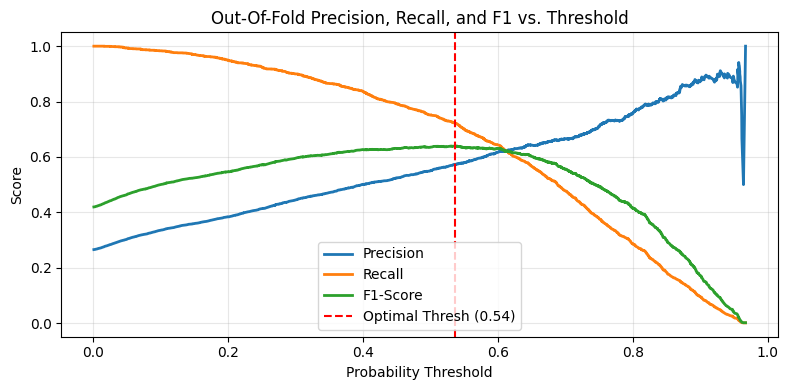

In [4]:
# Generate clean out-of-fold probability predictions on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs = cross_val_predict(pipeline_rf, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

oof_auc = roc_auc_score(y_train, oof_probs)
print(f"5-Fold Cross-Validation OOF ROC-AUC: {oof_auc:.4f}")

# Evaluate Precision, Recall, and F1 across decision thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Select threshold that maximizes F1 score on training folds
best_idx = np.argmax(f1_scores[:-1])
best_thresh = thresholds[best_idx]
print(f"Optimal OOF Decision Threshold: {best_thresh:.3f}")
print(f"OOF F1-Score at optimal threshold: {f1_scores[best_idx]:.4f}")
print(f"OOF Precision: {precisions[best_idx]:.4f} - Recall: {recalls[best_idx]:.4f}")

# Plot Precision & Recall vs Threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#1f77b4', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall', color='#ff7f0e', lw=2)
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='#2ca02c', lw=2)
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Optimal Thresh ({best_thresh:.2f})')
plt.title('Out-Of-Fold Precision, Recall, and F1 vs. Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Final Evaluation on Unseen Test Set
We now train the pipeline on the full `X_train` and evaluate **once** on the untouched `X_test`.


=== Unbiased Test Set Evaluation ===
Test ROC-AUC Score: 0.8466

Confusion Matrix:
[[820 215]
 [104 270]]

Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.89      0.79      0.84      1035
 Churned (1)       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



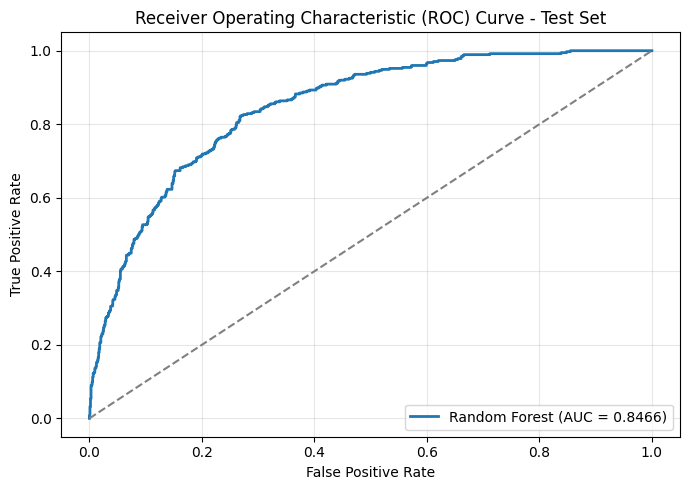

In [5]:
# Fit pipeline on entire training split
pipeline_rf.fit(X_train, y_train)

# Predict probabilities and apply the OOF-selected optimal threshold
y_prob_test = pipeline_rf.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_thresh).astype(int)

# Evaluation metrics
test_auc = roc_auc_score(y_test, y_prob_test)
print("=== Unbiased Test Set Evaluation ===")
print(f"Test ROC-AUC Score: {test_auc:.4f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Retained (0)', 'Churned (1)']))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'Random Forest (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Feature Importance Analysis
Let's inspect which features—including newly engineered ones—the Random Forest relies on most.


=== Top 20 Most Predictive Features ===
                       Feature  Importance
        Monthly_to_Total_Ratio    0.128448
   InternetService_Fiber optic    0.101651
             Contract_Two year    0.099518
                        tenure    0.096620
                MonthlyCharges    0.082563
                  TotalCharges    0.069420
             AvgMonthlyCharges    0.066130
PaymentMethod_Electronic check    0.051691
             Contract_One year    0.038698
               Is_New_Customer    0.035843
                    ChargeDiff    0.033895
            InternetService_No    0.033698
              Is_Long_Customer    0.031637
                 TotalServices    0.016465
                OnlineSecurity    0.015945
              PaperlessBilling    0.015268
                   TechSupport    0.013680
                 MultipleLines    0.007320
               StreamingMovies    0.006966
                   StreamingTV    0.006752


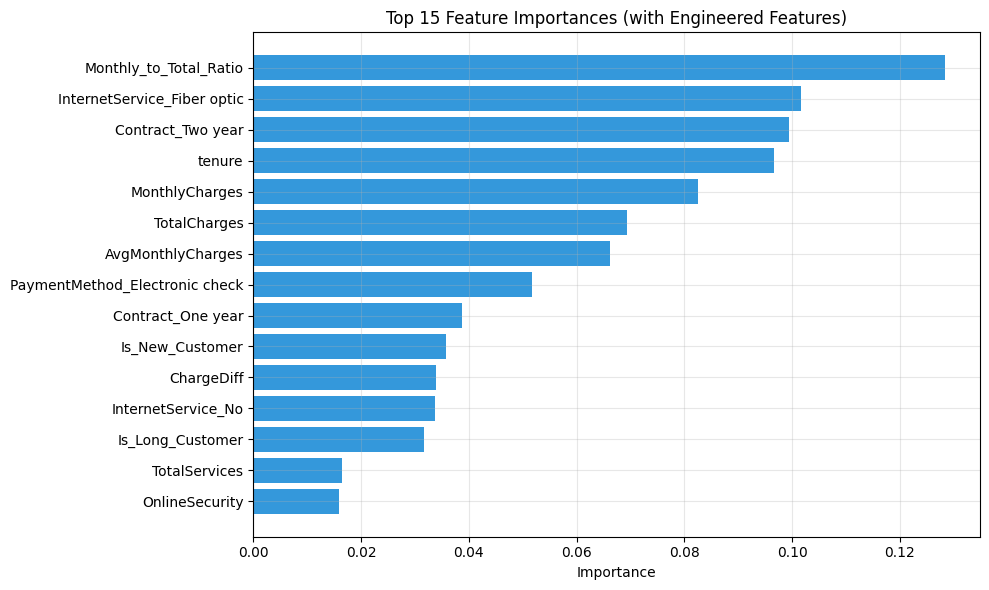

In [6]:
model = pipeline_rf.named_steps['classifier']
feature_names = pipeline_rf.named_steps['feature_engineer'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("=== Top 20 Most Predictive Features ===")
print(importance_df.head(20).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(10, 6))
top15 = importance_df.head(15).iloc[::-1]
plt.barh(top15['Feature'], top15['Importance'], color='#3498db')
plt.title('Top 15 Feature Importances (with Engineered Features)')
plt.xlabel('Importance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Individual Customer Decision Path Tracing
We can trace the exact split decisions for individual customers using `trace_customer_path`.


In [7]:
# Preprocess a sample customer from test set
sample_customer_raw = X_test.head(1)
sample_clean = pipeline_rf.named_steps['cleaner'].transform(sample_customer_raw)
sample_fe = pipeline_rf.named_steps['feature_engineer'].transform(sample_clean)

# Trace the decision path through an agreeing tree in the forest
trace_customer_path(pipeline_rf, sample_fe, customer_idx=0)


[INFO] RandomForest detected - Ensemble voted: 0 (20.9% churn prob)
[INFO] 254/300 trees agreed with ensemble vote. Selected Tree #170 (tree pred: 0)
Customer's Decision Path (Node IDs): [0, 1, 47, 48, 84, 85, 95, 103, 104, 106]
Final Leaf Node: 106
Node 0 (Split Node):
  - Feature checked: 'Monthly_to_Total_Ratio'
  - Tree rule: <= 0.0461
  - Customer's value: 0.01346644311150994  ->  Goes LEFT (<=)
----------------------------------------
Node 1 (Split Node):
  - Feature checked: 'TotalCharges'
  - Tree rule: <= 1993.3750
  - Customer's value: 8468.2  ->  Goes RIGHT (>)
----------------------------------------
Node 47 (Split Node):
  - Feature checked: 'Contract_Two year'
  - Tree rule: <= 0.5000
  - Customer's value: 0.0  ->  Goes LEFT (<=)
----------------------------------------
Node 48 (Split Node):
  - Feature checked: 'PaperlessBilling'
  - Tree rule: <= 0.5000
  - Customer's value: 1.0  ->  Goes RIGHT (>)
----------------------------------------
Node 84 (Split Node):
  - Featu

## 7. Save the Improved Pipeline
Save the fitted pipeline for deployment or API inference.


In [8]:
output_model_path = 'pipeline_improved.pkl'
joblib.dump(pipeline_rf, output_model_path)
print(f"Successfully saved improved pipeline to: {output_model_path}")


Successfully saved improved pipeline to: pipeline_improved.pkl
